# Calculate the metrics from the csv

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

In [12]:
# --- Define models and their respective CSV paths ---
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_closed_image/closed_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_closed_image/closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")




Processing DINOv2 (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping 'closed' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 25.03it/s]



Processing DINOv2 (Image)
-> Pre-calculating sorted match matrix...
-> Bootstrapping 'closed' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 26.53it/s]



Processing SwinV2 (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping 'closed' metrics from CSV (100 iterations)...


...

100%|██████████| 100/100 [00:03<00:00, 26.09it/s]



Processing ViT (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping 'closed' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 25.91it/s]



Processing ViT (Image)
-> Pre-calculating sorted match matrix...
-> Bootstrapping 'closed' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 25.79it/s]


In [13]:

# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename for results
FILENAME = f"closed_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print("✅ Results saved successfully.")


-> Saving all results to results_data\closed_world_benchmarks.pkl...
✅ Results saved successfully.


In [14]:
# Load the saved data
LOAD_PATH = "results_data/closed_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")


Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [15]:
# --- Print results ---
print("\n" + "="*110)
print(f"{'Model':<25} | {'mAP [95% CI]':<25} | {'Rank-1 [95% CI]':<25} | {'Rank-5 [95% CI]':<25}")
print("="*110)

for name, res in all_results.items():
    # mAP with Confidence Interval
    m_mean = res['mAP_mean']
    m_low  = res.get('mAP_lower', 0)
    m_high = res.get('mAP_upper', 0)
    map_str = f"{m_mean:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 
    r1_m = res['cmc_mean'][0]
    r1_l = res['cmc_lower'][0]
    r1_u = res['cmc_upper'][0]
    r1_str = f"{r1_m:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['cmc_mean']) >= 5 else -1
    r5_m = res['cmc_mean'][idx]
    r5_l = res['cmc_lower'][idx]
    r5_u = res['cmc_upper'][idx]
    r5_str = f"{r5_m:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<25} | {map_str:<25} | {r1_str:<25} | {r5_str:<25}")

print("-" * 110)


Model                     | mAP [95% CI]              | Rank-1 [95% CI]           | Rank-5 [95% CI]          
DINOv2 (Video)            | 0.544 [0.522-0.570]       | 0.585 [0.555-0.610]       | 0.783 [0.755-0.807]      
DINOv2 (Image)            | 0.443 [0.421-0.462]       | 0.449 [0.419-0.470]       | 0.666 [0.642-0.692]      
SwinV2 (Video)            | 0.284 [0.263-0.303]       | 0.269 [0.238-0.292]       | 0.518 [0.490-0.547]      
SwinV2 (Image)            | 0.214 [0.199-0.228]       | 0.201 [0.182-0.219]       | 0.387 [0.358-0.409]      
ViT (Video)               | 0.307 [0.286-0.326]       | 0.313 [0.288-0.336]       | 0.540 [0.511-0.569]      
ViT (Image)               | 0.224 [0.209-0.240]       | 0.205 [0.186-0.226]       | 0.410 [0.385-0.436]      
--------------------------------------------------------------------------------------------------------------


C:\Users\marko\AppData\Local\Temp\ipykernel_18512\1323186071.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


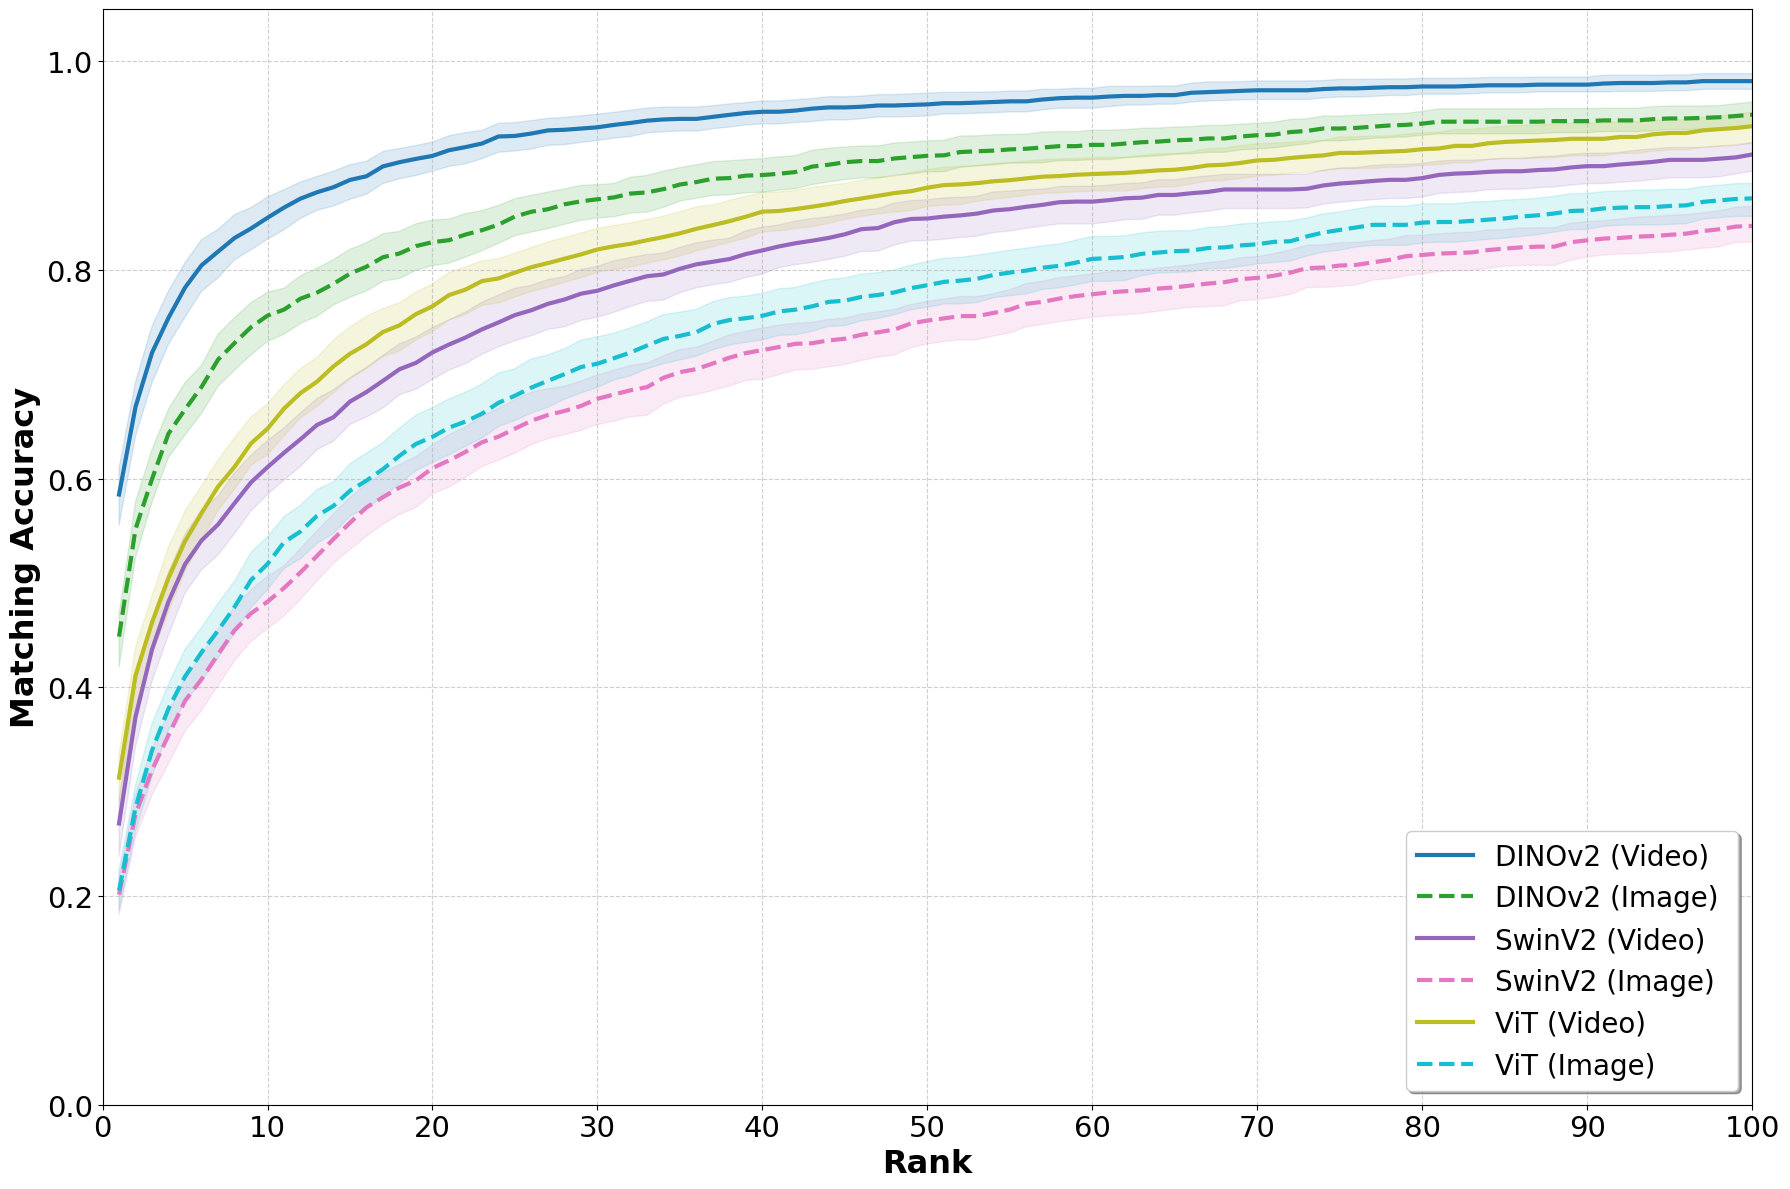

In [16]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_RANK = 100      
TICK_STEP = 10    
FONT_SIZE = 21       

# -------------------------------------------------------------
# --- Plotting CMC Curves with Confidence Intervals ---
# -------------------------------------------------------------

plt.figure(figsize=(18, 12))
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    ranks = res["ranks"]
    cmc_mean = res["cmc_mean"]
    cmc_lower = res["cmc_lower"]
    cmc_upper = res["cmc_upper"]
    color = colors(i)
    
    # Plot the Shaded Uncertainty Interval (95% CI)
    plt.fill_between(ranks, cmc_lower, cmc_upper, color=color, alpha=0.15)
    
    # Plot the Mean Line
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(ranks, cmc_mean, color=color, linestyle=line_style, linewidth=3, 
             label=f"{name} ")

# --- Format the Plot with Larger Fonts ---
plt.xlabel("Rank", fontsize=FONT_SIZE + 2, fontweight='bold')
plt.ylabel("Matching Accuracy", fontsize=FONT_SIZE + 2, fontweight='bold')

# --- Axis Tick Labels ---
plt.xticks(np.arange(0, MAX_RANK + 1, step=TICK_STEP), fontsize=FONT_SIZE)
plt.yticks(np.arange(0, 1.05, step=0.2), fontsize=FONT_SIZE)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_RANK) 
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend Configuration ---
# Placed in lower right as CMC curves typically trend upward
plt.legend(fontsize=FONT_SIZE - 1, loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/closed_world.png")
plt.show()
